In [ ]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPool2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets.fashion_mnist import load_data
from keras.utils import to_categorical
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

# Fashion MNIST 데이터세트
# Label     Category
# 0         티셔츠/상의
# 1         바지
# 2         스웨터
# 3         드레스
# 4         코트
# 5         샌들
# 6         셔츠
# 7         운동화
# 8         가방
# 9         부츠

In [2]:
(x_train, y_train),(x_test, y_test) = load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

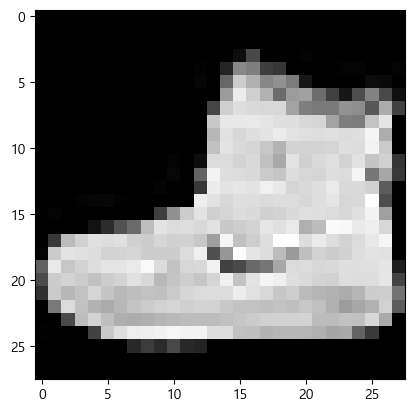

In [4]:
plt.imshow( x_train[0], cmap='gray')
plt.show()

In [5]:
y_train[0]

np.uint8(9)

In [6]:
model = Sequential()
model.add( Flatten( input_shape=(28,28) ) ) # x = x.reshape(n,28*28)
model.add( Dense( units=64, activation='relu')) #w:784x64  z = matmul(x,w)+b hx=relu(z)
model.add( Dense( units=32, activation='relu')) #w: 64x32   z = matmul(hx, w) +b hx=relu(z)
model.add( Dense( units=10, activation='softmax')) #w: 32x10  z= matmul(hx,w)+b hx=softmax(z)
model.compile( loss='sparse_categorical_crossentropy', optimizer='adam',metrics=['acc'])
model.fit(x_train/255, y_train, epochs=10)

c:\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.8177 - loss: 0.5193
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8600 - loss: 0.3840
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.8728 - loss: 0.3475
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.8819 - loss: 0.3221
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.8867 - loss: 0.3075
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.8919 - loss: 0.2927
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8947 - loss: 0.2815
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8979 - loss: 0.2716
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9022 - loss: 0.2623
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9054 - loss: 0.2554


In [9]:
from sklearn.metrics import confusion_matrix

In [12]:
pred = model.predict( x_train/255 ).argmax(axis=1)
confusion_matrix( y_train, pred)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 742us/step


array([[5276,    6,  114,  132,   11,    0,  449,    1,   11,    0],
       [   3, 5944,    2,   41,    5,    0,    1,    0,    3,    1],
       [  45,    3, 5364,   36,  293,    0,  250,    0,    9,    0],
       [  99,   73,   59, 5483,  184,    0,   94,    0,    8,    0],
       [   6,    4,  685,  130, 4818,    0,  350,    0,    7,    0],
       [   0,    0,    0,    0,    0, 5932,    0,   50,    2,   16],
       [ 651,    9,  565,   99,  248,    0, 4408,    0,   20,    0],
       [   0,    0,    0,    0,    0,   37,    0, 5874,    2,   87],
       [   7,    3,   15,    8,    5,    1,   25,    5, 5931,    0],
       [   0,    0,    0,    0,    0,   25,    0,  168,    0, 5807]])

## cnn

In [ ]:
conv = Conv2D( 32, kernel_size=(3,3), strides=1, input_shape=(28,28,1) )
conv(  x_train[0].reshape( 1,28,28,1)/255  )

c:\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<tf.Tensor: shape=(1, 26, 26, 32), dtype=float32, numpy=
array([[[[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          

In [ ]:
conv = Conv2D( 32, kernel_size=(3,3), strides=1, input_shape=(28,28,1) )
c = conv(  x_train[0].reshape( 1,28,28,1)/255  )
# c =Conv2D(64, kernel_size=(3,3), activation='relu')(c)
conv = Conv2D(64, kernel_size=(3,3), activation='relu')
c = conv(c) #1, 24, 24, 64
mx = MaxPool2D( pool_size=(2,2))(c) 
mx #1,12,12,64

c:\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<tf.Tensor: shape=(1, 12, 12, 64), dtype=float32, numpy=
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [4.55507718e-04, 0.00000000e+00, 1.03311206e-03, ...,
          1.69347450e-02, 2.90163960e-02, 0.00000000e+00],
         [0.00000000e+00, 1.36904418e-03, 2.66093120e-04, ...,
          1.90713629e-03, 5.99018624e-03, 0.00000000e+00],
         [2.17557186e-03, 2.32236949e-03, 0.00000000e+00, ...,
          2.66668899e-03, 1.73295895e-03, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          

In [15]:
12*12*64

9216

In [ ]:
# 학습대상 w
# 1. 3x3X32
# 2. 3x3X64
# 3.9216x64
# 4. 464x10
model = Sequential()
## 특징추출기
model.add( Conv2D( 32, kernel_size=(3,3), strides=1, 
                  input_shape=(28,28,1),activation='relu' , padding='same' ) )
# shape=(6000, 26, 26, 32)
model.add( Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add( MaxPool2D( pool_size=(2,2)) ) # 60000,12,12,64
## 분류기
model.add( Flatten() )
model.add( Dense(units=64, activation='relu')) #10816x64
model.add( Dense(units=10, activation='softmax')) #64x10
model.compile( loss='sparse_categorical_crossentropy', optimizer='adam',metrics=['acc'])
#model.summary()
model.fit( x_train.reshape(60000,28,28,1)/255, y_train, epochs=10 )


c:\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - acc: 0.8608 - loss: 0.3901
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - acc: 0.9112 - loss: 0.2460
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - acc: 0.9277 - loss: 0.1979
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - acc: 0.9408 - loss: 0.1604
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - acc: 0.9524 - loss: 0.1293
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - acc: 0.9620 - loss: 0.1028
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - acc: 0.9693 - loss: 0.0827
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - acc: 0.9762 - loss: 0.0655
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - acc: 0.9806 - loss: 0.0535
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - acc: 0.9843 - loss: 0.0436


In [ ]:
x = model.layers[0]( x_test[0].reshape(1,28,28,1)/255 )
x = model.layers[1](x)
x = model.layers[2](x) #maxpool
x = model.layers[3](x)  # (1,  13*13*64))
x = model.layers[4](x) #(1, 10816)  (10816x64)
x = model.layers[5](x) #(1, 64)  (64x10)
x

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[1.1182832e-13, 2.4362919e-21, 2.9489303e-14, 9.9862844e-22,
        9.3480580e-15, 9.9332782e-12, 5.7647974e-15, 9.6062609e-11,
        2.2521145e-17, 1.0000000e+00]], dtype=float32)>

In [33]:
model.predict( x_test[0].reshape(1,28,28,1)/255)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[1.1182832e-13, 2.4362919e-21, 2.9489303e-14, 9.9862844e-22,
        9.3480580e-15, 9.9332782e-12, 5.7647974e-15, 9.6062609e-11,
        2.2521145e-17, 1.0000000e+00]], dtype=float32)

In [18]:
x_test[0].shape

(28, 28)

In [ ]:
model.predict( x_test[0].reshape(1,28,28,1)/255).argmax( axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([9])

In [21]:
y_test[0]

np.uint8(9)